# 05 - The three-horse race: PTO vs black box vs DFL (simulation)

Evaluation-only notebook: no training happens here. It reads the per-date wide result
frames saved by `02_pto_simulated_panel`, `03_blackbox_simulated_panel` and
`04_dfl_simulated_panel` (run those first), merges them on the shared test dates, and
compares the three learning approaches on one canvas.

What it produces:

- **Cross-notebook consistency audit**: the decision environment (oracles, true PD,
  K_IRB_true) must be bit-identical across the three files, and the PTO models re-run
  inside notebooks 03/04 must match notebook 02 - otherwise the comparison is not
  apples-to-apples and the audit says so before anything else is computed.
- **Summary table**: PD accuracy vs true and realised PD (models with a PD
  intermediate), mean/median/tail regret, regret vs the Bayes oracle, win share,
  allocation gaps vs both oracles, CE-decision ablation columns where available.
- **Regime split**: mean regret in the top-decile true-PD quarters vs calm quarters -
  decision-focused training should earn its keep in the tail where the shortfall binds.
- **Pairwise Diebold-Mariano matrices** (Newey-West + Harvey adjustment, identical
  machinery to the source notebooks): per-period regret for every pair, squared PD
  error vs TRUE PD for PD-carrying pairs; heatmap with significance stars.
- **Figure set**: allocation paths vs both oracles, per-period + cumulative regret,
  rolling regret, regret distributions, mean-regret decomposition
  (closable vs irreducible), allocation-vs-oracle scatters, PD intermediates vs true
  PD (the auditability panel - the black box has nothing to plot there by design),
  forecast-accuracy-vs-decision-quality scatter (the thesis punchline figure), and
  the cumulative utility gap vs PTO.

Tables go to `models/notebooks/results/horserace_*`, figures to `figures/sim_horserace/`.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy import stats

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "models" / "notebooks" / "results" / "pto_sim_predictions_main.csv").exists():
    ROOT = ROOT.parent

RESULTS_DIR = ROOT / "models" / "notebooks" / "results"
FIGURES_DIR = ROOT / "figures" / "sim_horserace"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SPLIT = "main"
SOURCES = {
    "pto": RESULTS_DIR / f"pto_sim_predictions_{SPLIT}.csv",
    "blackbox": RESULTS_DIR / f"blackbox_sim_predictions_{SPLIT}.csv",
    "dfl": RESULTS_DIR / f"dfl_sim_predictions_{SPLIT}.csv",
}
for name, p in SOURCES.items():
    print(f"{name}: {p} {'FOUND' if p.exists() else 'MISSING - run that notebook first'}")

# Model taxonomy. PD_MODELS carry an auditable PD intermediate; ALPHA_ONLY do not.
PTO_MODELS = ["linear", "mlp"]
BB_MODELS = ["blackbox_linear", "blackbox_mlp"]
DFL_MODELS = ["dfl_linear", "dfl_mlp"]
BASELINES = ["persistence", "persistence_ma4"]
ALL_MODELS = PTO_MODELS + BB_MODELS + DFL_MODELS + BASELINES
PD_MODELS = PTO_MODELS + DFL_MODELS + BASELINES
HEADLINE = ["mlp", "blackbox_mlp", "dfl_mlp"]          # the three-horse race, MLP class
HEADLINE_LINEAR = ["linear", "blackbox_linear", "dfl_linear"]

MODEL_COLORS = {"linear": "#2166ac", "mlp": "#2166ac",
                "blackbox_linear": "#7b3294", "blackbox_mlp": "#7b3294",
                "dfl_linear": "#1b7837", "dfl_mlp": "#1b7837",
                "persistence": "#bfbfbf", "persistence_ma4": "#a6761d"}
MODEL_LS = {m: ("--" if m.endswith("linear") and not m.startswith("persistence") else "-") for m in ALL_MODELS}
MODEL_LABELS = {"linear": "PTO linear", "mlp": "PTO MLP",
                "blackbox_linear": "Black-box linear", "blackbox_mlp": "Black-box MLP",
                "dfl_linear": "DFL linear", "dfl_mlp": "DFL MLP",
                "persistence": "Persistence (raw)", "persistence_ma4": "Persistence (4Q mean)"}
ORACLE_COLOR, BAYES_COLOR, TRUE_COLOR = "#1a1a1a", "#5aae61", "#333333"
ROLL_WINDOW = 20  # quarters, for rolling-mean regret

plt.rcdefaults()
plt.rcParams.update({"font.size": 10, "axes.linewidth": 0.8, "xtick.direction": "out",
                     "ytick.direction": "out", "xtick.major.size": 3, "ytick.major.size": 3,
                     "font.sans-serif": ["DejaVu Sans"]})

def format_date_axis(ax, plot_df):
    years = plot_df["date"].dt.year
    step = max(2, int(np.ceil((years.max() - years.min()) / 10)))
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.28)

def savefig(fig, name):
    fig.savefig(FIGURES_DIR / name, dpi=200, bbox_inches="tight")


pto: /Users/hannahokeeffe/Documents/Imperial/DFL_New/models/notebooks/results/pto_sim_predictions_main.csv FOUND
blackbox: /Users/hannahokeeffe/Documents/Imperial/DFL_New/models/notebooks/results/blackbox_sim_predictions_main.csv FOUND
dfl: /Users/hannahokeeffe/Documents/Imperial/DFL_New/models/notebooks/results/dfl_sim_predictions_main.csv FOUND


## Load, audit, and merge

PTO and baseline columns come from notebook 02, `blackbox_*` from 03, `dfl_*` from 04.
The overlapping PTO re-runs in 03/04 exist purely so each notebook's internal DM tests
share test dates; here the overlap doubles as a config-drift detector.

In [2]:
# Load the three wide result frames and merge them into one canonical frame.
#
# Each source notebook re-runs the PTO models and baselines on identical expanding
# windows, so the three files OVERLAP on those columns. The merge takes each family
# from its home notebook (PTO + baselines from 02, blackbox_* from 03, dfl_* from 04)
# and the overlap becomes a cross-notebook consistency audit: if the re-run PTO columns
# differ across files, the notebooks were run with different configs/seeds and the
# horse race is not apples-to-apples.
frames = {name: pd.read_csv(path, parse_dates=["date"]) for name, path in SOURCES.items()}
for name, f in frames.items():
    print(f"{name}: {len(f)} rows, {f['date'].min().date()} to {f['date'].max().date()}")

# --- cross-notebook consistency audit ---------------------------------------------------
ORACLE_COLS = ["alpha_oracle", "utility_oracle", "alpha_bayes", "utility_bayes_realised",
               "regret_irreducible", "pd_q_true", "pd_q_realised", "k_irb_true"]
PTO_OVERLAP = ([f"{m}_{mod}" for m in ["regret", "alpha_hat", "pd_q_hat", "utility"]
                for mod in PTO_MODELS + BASELINES])
audit_rows = []
base = frames["pto"].set_index("date")
for other in ["blackbox", "dfl"]:
    o = frames[other].set_index("date")
    shared = base.index.intersection(o.index)
    for col in ORACLE_COLS + PTO_OVERLAP:
        if col not in base.columns or col not in o.columns:
            continue
        diff = float(np.nanmax(np.abs(base.loc[shared, col].to_numpy(dtype=float)
                                      - o.loc[shared, col].to_numpy(dtype=float))))
        audit_rows.append({"source": other, "column": col, "max_abs_diff": diff})
audit = pd.DataFrame(audit_rows)
worst = audit.sort_values("max_abs_diff", ascending=False).head(10)
display(worst)
oracle_bad = audit[audit["column"].isin(ORACLE_COLS) & (audit["max_abs_diff"] > 1e-9)]
assert oracle_bad.empty, ("Oracle/environment columns differ across notebooks - the decision "
                          "environments are not identical:\n" + oracle_bad.to_string())
pto_drift = audit[~audit["column"].isin(ORACLE_COLS) & (audit["max_abs_diff"] > 1e-9)]
if not pto_drift.empty:
    print("WARNING: re-run PTO/baseline columns differ across notebooks (config or seed drift). "
          "The horse race remains valid per-notebook, but interpret cross-family gaps with care.")
    display(pto_drift)
else:
    print("Consistency audit passed: identical environments and identical PTO re-runs across all three notebooks.")

# --- canonical merged frame -------------------------------------------------------------
BASE_COLS = ["date", "c_q_realised", "pd_q_realised", "pd_q_true", "pd_a_true", "k_irb_true",
             "alpha_oracle", "utility_oracle", "alpha_bayes", "utility_bayes_realised",
             "regret_irreducible"]
def cols_for(models, frame):
    metrics = ["pd_q_hat", "pd_a_hat", "k_irb_hat", "alpha_hat", "alpha_hat_ce",
               "utility", "utility_ce", "regret", "regret_ce", "regret_vs_bayes"]
    return [f"{m}_{mod}" for m in metrics for mod in models if f"{m}_{mod}" in frame.columns]

merged = frames["pto"][BASE_COLS + cols_for(PTO_MODELS + BASELINES, frames["pto"])].copy()
merged = merged.merge(frames["blackbox"][["date"] + cols_for(BB_MODELS, frames["blackbox"])], on="date", how="inner")
merged = merged.merge(frames["dfl"][["date"] + cols_for(DFL_MODELS, frames["dfl"])], on="date", how="inner")
merged = merged.sort_values("date").reset_index(drop=True)
ALL_MODELS = [m for m in ALL_MODELS if f"regret_{m}" in merged.columns]
PD_MODELS = [m for m in PD_MODELS if f"pd_q_hat_{m}" in merged.columns and merged[f"pd_q_hat_{m}"].notna().any()]
print(f"Merged horse-race frame: {len(merged)} shared test dates; models: {ALL_MODELS}")
display(merged.head())


pto: 300 rows, 2155-01-01 to 2229-10-01
blackbox: 300 rows, 2155-01-01 to 2229-10-01
dfl: 300 rows, 2155-01-01 to 2229-10-01


,source,column,max_abs_diff
45,dfl,utility_mlp,0.800541
33,dfl,regret_mlp,0.800541
44,dfl,utility_linear,0.493202
32,dfl,regret_linear,0.493202
37,dfl,alpha_hat_mlp,0.050000
36,dfl,alpha_hat_linear,0.030000
41,dfl,pd_q_hat_mlp,0.002962
40,dfl,pd_q_hat_linear,0.001307
26,dfl,alpha_bayes,0.000000
27,dfl,utility_bayes_realised,0.000000


,source,column,max_abs_diff
32,dfl,regret_linear,0.493202
33,dfl,regret_mlp,0.800541
36,dfl,alpha_hat_linear,0.030000
37,dfl,alpha_hat_mlp,0.050000
40,dfl,pd_q_hat_linear,0.001307
41,dfl,pd_q_hat_mlp,0.002962
44,dfl,utility_linear,0.493202
45,dfl,utility_mlp,0.800541


Merged horse-race frame: 300 shared test dates; models: ['linear', 'mlp', 'blackbox_linear', 'blackbox_mlp', 'dfl_linear', 'dfl_mlp', 'persistence', 'persistence_ma4']


,date,c_q_realised,pd_q_realised,pd_q_true,pd_a_true,k_irb_true,alpha_oracle,utility_oracle,alpha_bayes,utility_bayes_realised,...,utility_dfl_linear,utility_dfl_mlp,utility_ce_dfl_linear,utility_ce_dfl_mlp,regret_dfl_linear,regret_dfl_mlp,regret_ce_dfl_linear,regret_ce_dfl_mlp,regret_vs_bayes_dfl_linear,regret_vs_bayes_dfl_mlp
0,2155-01-01,0.004250,0.009444,0.002500,0.009964,0.073759,0.52,1.097892,0.50,1.094127,...,1.090362,1.086596,1.096009,1.092244,0.007530,0.011295,0.001883,0.005648,0.003765,0.007530
1,2155-04-01,0.000970,0.002155,0.003205,0.012760,0.080270,0.50,1.118728,0.47,1.111604,...,1.109229,1.104480,1.116353,1.113978,0.009498,0.014247,0.002375,0.004749,0.002375,0.007124
2,2155-07-01,0.000046,0.000102,0.003074,0.012239,0.079179,0.51,1.128168,0.48,1.120628,...,1.113089,1.113089,1.123141,1.120628,0.015079,0.015079,0.005026,0.007539,0.007539,0.007539
3,2155-10-01,0.000037,0.000082,0.002833,0.011285,0.077048,0.52,1.130753,0.48,1.120695,...,1.105608,1.110637,1.115666,1.120695,0.025145,0.020116,0.015087,0.010058,0.015087,0.010058
4,2156-01-01,0.000282,0.000627,0.003089,0.012297,0.079304,0.51,1.126360,0.47,1.116449,...,1.104061,1.111494,1.113972,1.118927,0.022299,0.014866,0.012388,0.007433,0.012388,0.004955


## Summary metrics and regime split

In [3]:
# Headline summary table: forecast accuracy (where a PD intermediate exists) and
# decision quality, one row per model. `win_share` is the fraction of test dates on
# which the model attains the lowest regret among ALL_MODELS (ties split equally).
def summary_table(df, models):
    regret_mat = np.column_stack([df[f"regret_{m}"].to_numpy() for m in models])
    is_min = np.isclose(regret_mat, regret_mat.min(axis=1, keepdims=True), atol=1e-12)
    win_w = is_min / is_min.sum(axis=1, keepdims=True)
    rows = []
    for j, m in enumerate(models):
        r = df[f"regret_{m}"]
        row = {"model": MODEL_LABELS.get(m, m), "n": len(df),
               "mean_regret": r.mean(), "median_regret": r.median(), "std_regret": r.std(),
               "q95_regret": r.quantile(0.95), "max_regret": r.max(),
               "mean_regret_vs_bayes": df.get(f"regret_vs_bayes_{m}", pd.Series(np.nan, index=df.index)).mean(),
               "mean_utility": df[f"utility_{m}"].mean(),
               "win_share": float(win_w[:, j].sum() / len(df)),
               "mean_abs_alpha_gap_oracle": (df[f"alpha_hat_{m}"] - df["alpha_oracle"]).abs().mean(),
               "mean_abs_alpha_gap_bayes": (df[f"alpha_hat_{m}"] - df["alpha_bayes"]).abs().mean(),
               "corr_alpha_oracle": df[f"alpha_hat_{m}"].corr(df["alpha_oracle"])}
        if m in PD_MODELS:
            err_true = df[f"pd_q_hat_{m}"] - df["pd_q_true"]
            err_real = df[f"pd_q_hat_{m}"] - df["pd_q_realised"]
            row.update({"rmse_pd_vs_true": float(np.sqrt((err_true ** 2).mean())),
                        "mae_pd_vs_true": err_true.abs().mean(),
                        "bias_pd_vs_true": err_true.mean(),
                        "rmse_pd_vs_realised": float(np.sqrt((err_real ** 2).mean()))})
        if f"regret_ce_{m}" in df.columns:
            row["mean_regret_ce"] = df[f"regret_ce_{m}"].mean()
        rows.append(row)
    return pd.DataFrame(rows).set_index("model")

summary = summary_table(merged, ALL_MODELS)
display(summary.round(6))
summary.to_csv(RESULTS_DIR / f"horserace_summary_{SPLIT}.csv")

# Mean-regret decomposition check per model: mean regret = mean regret_vs_bayes + mean irreducible.
irr = merged["regret_irreducible"].mean()
print(f"Mean irreducible regret (foresight minus Bayes; identical for every model): {irr:.6f}")

# Regime split: where do the horses separate? Compare mean regret in the top-decile
# true-PD quarters (stress) vs the rest (calm). Decision-focused training should earn
# its keep in the tail, where the shortfall penalty binds.
stress_mask = merged["pd_q_true"] >= merged["pd_q_true"].quantile(0.9)
regime = pd.DataFrame({
    MODEL_LABELS.get(m, m): {
        "mean_regret_calm": merged.loc[~stress_mask, f"regret_{m}"].mean(),
        "mean_regret_stress_top_decile_PD": merged.loc[stress_mask, f"regret_{m}"].mean(),
    } for m in ALL_MODELS}).T
regime["stress_to_calm_ratio"] = regime["mean_regret_stress_top_decile_PD"] / regime["mean_regret_calm"]
display(regime.round(6))
regime.to_csv(RESULTS_DIR / f"horserace_regime_{SPLIT}.csv")


,n,mean_regret,median_regret,std_regret,q95_regret,max_regret,mean_regret_vs_bayes,mean_utility,win_share,mean_abs_alpha_gap_oracle,mean_abs_alpha_gap_bayes,corr_alpha_oracle,rmse_pd_vs_true,mae_pd_vs_true,bias_pd_vs_true,rmse_pd_vs_realised,mean_regret_ce
model,,,,,,,,,,,,,,,,,
PTO linear,300,0.132534,0.012225,0.307995,0.772926,3.159464,0.117968,0.991904,0.330556,0.038467,0.030033,0.792587,0.001356,0.000779,-0.000281,0.010328,0.325722
PTO MLP,300,0.057083,0.009896,0.190374,0.359765,2.385378,0.042517,1.067355,0.313889,0.038400,0.024167,0.811322,0.001270,0.000722,-0.000100,0.010258,0.200556
Black-box linear,300,0.021633,0.017407,0.050798,0.032153,0.837206,0.007066,1.102806,0.028056,0.076100,0.046133,0.789154,NaN,NaN,NaN,NaN,NaN
Black-box MLP,300,0.024581,0.016664,0.118438,0.027672,1.998335,0.010015,1.099858,0.018611,0.071700,0.041267,0.798952,NaN,NaN,NaN,NaN,NaN
DFL linear,300,0.035581,0.019573,0.152399,0.035081,2.385378,0.021015,1.088858,0.081111,0.076200,0.049100,0.722023,0.003259,0.001607,0.001209,0.010611,0.091205
DFL MLP,300,0.023690,0.015097,0.137103,0.027269,2.385378,0.009124,1.100749,0.047500,0.067333,0.038100,0.774336,0.002731,0.001164,0.000815,0.010428,0.066656
Persistence (raw),300,3.007579,2.198739,3.016159,8.397658,11.335889,2.993012,-1.883140,0.047222,0.204100,0.215000,0.435294,0.010445,0.003393,0.000091,0.014485,3.202134
Persistence (4Q mean),300,1.274353,0.360464,1.737662,5.077921,7.847257,1.259787,-0.149915,0.133056,0.110567,0.115400,0.509396,0.005764,0.002379,0.000129,0.011469,1.510849


Mean irreducible regret (foresight minus Bayes; identical for every model): 0.014566


,mean_regret_calm,mean_regret_stress_top_decile_PD,stress_to_calm_ratio
PTO linear,0.125201,0.198531,1.585694
PTO MLP,0.042166,0.191338,4.537707
Black-box linear,0.019450,0.041279,2.122303
Black-box MLP,0.018673,0.077755,4.164078
DFL linear,0.028607,0.098350,3.437960
DFL MLP,0.016231,0.090821,5.595523
Persistence (raw),3.182588,1.432493,0.450103
Persistence (4Q mean),1.379222,0.330536,0.239654


## Pairwise Diebold-Mariano tests

Negative statistic: the ROW model has lower loss than the COLUMN model. Stars:
\*\*\* p<0.01, \*\* p<0.05, \* p<0.1. With ~300 simulated test quarters these
have real power, unlike the empirical splits.

DM on per-period regret (row vs column; negative => row better):


,linear,mlp,blackbox_linear,blackbox_mlp,dfl_linear,dfl_mlp,persistence,persistence_ma4
linear,NaN,4.80,5.54,5.65,5.61,5.64,-15.80,-7.29
mlp,-4.80,NaN,3.47,4.10,3.16,4.22,-16.26,-7.74
blackbox_linear,-5.54,-3.47,NaN,-0.73,-2.33,-0.39,-16.70,-7.96
blackbox_mlp,-5.65,-4.10,0.73,NaN,-2.99,0.43,-16.60,-7.92
dfl_linear,-5.61,-3.16,2.33,2.99,NaN,3.17,-16.52,-7.89
dfl_mlp,-5.64,-4.22,0.39,-0.43,-3.17,NaN,-16.57,-7.92
persistence,15.80,16.26,16.70,16.60,16.52,16.57,NaN,11.04
persistence_ma4,7.29,7.74,7.96,7.92,7.89,7.92,-11.04,NaN


,linear,mlp,blackbox_linear,blackbox_mlp,dfl_linear,dfl_mlp,persistence,persistence_ma4
linear,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0
mlp,0.0,NaN,0.0006,0.0001,0.0017,0.0000,0.0,0.0
blackbox_linear,0.0,0.0006,NaN,0.4648,0.0204,0.6941,0.0,0.0
blackbox_mlp,0.0,0.0001,0.4648,NaN,0.0030,0.6689,0.0,0.0
dfl_linear,0.0,0.0017,0.0204,0.0030,NaN,0.0017,0.0,0.0
dfl_mlp,0.0,0.0000,0.6941,0.6689,0.0017,NaN,0.0,0.0
persistence,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0
persistence_ma4,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,NaN


DM on squared PD error vs TRUE PD (PD models only):


,linear,mlp,dfl_linear,dfl_mlp,persistence,persistence_ma4
linear,NaN,0.82,-1.41,-1.08,-1.34,-1.45
mlp,-0.82,NaN,-1.41,-1.09,-1.34,-1.45
dfl_linear,1.41,1.41,NaN,2.74,-1.33,-1.30
dfl_mlp,1.08,1.09,-2.74,NaN,-1.35,-1.43
persistence,1.34,1.34,1.33,1.35,NaN,1.18
persistence_ma4,1.45,1.45,1.30,1.43,-1.18,NaN


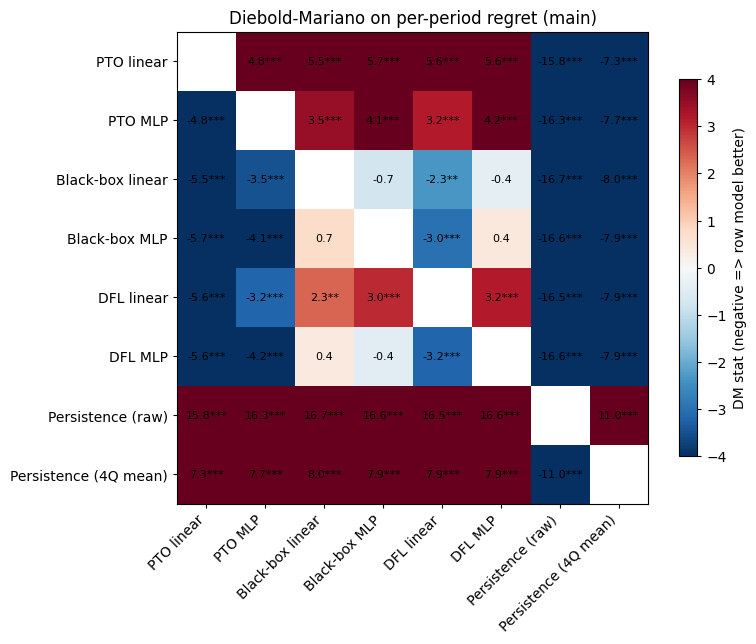

In [4]:
# Pairwise Diebold-Mariano tests, identical machinery to the source notebooks
# (Newey-West long-run variance, Harvey small-sample adjustment). Negative stat =>
# ROW model has lower loss than COLUMN model. Regret DM for every pair; squared
# PD error vs TRUE PD for pairs where both carry a PD intermediate.
def newey_west_lrv(d, lags):
    d = np.asarray(d, dtype=float)
    d = d - d.mean()
    n = len(d)
    v = float(np.mean(d * d))
    for k in range(1, min(lags, n - 1) + 1):
        w = 1.0 - k / (lags + 1.0)
        v += 2.0 * w * float(np.mean(d[k:] * d[:-k]))
    return v / n

def dm_test(loss_a, loss_b, nw_lags=4):
    d = np.asarray(loss_a, dtype=float) - np.asarray(loss_b, dtype=float)
    n = len(d)
    lrv = newey_west_lrv(d, nw_lags)
    if not np.isfinite(lrv) or lrv <= 0:
        return float("nan"), float("nan")
    stat = (d.mean() / np.sqrt(lrv)) * np.sqrt((n - 1.0) / n)
    p_value = 2.0 * stats.t.sf(abs(stat), df=n - 1)
    return float(stat), float(p_value)

def dm_matrix(df, models, loss_fn):
    stat = pd.DataFrame(np.nan, index=models, columns=models, dtype=float)
    pval = pd.DataFrame(np.nan, index=models, columns=models, dtype=float)
    for a in models:
        for b in models:
            if a == b:
                continue
            la, lb = loss_fn(df, a), loss_fn(df, b)
            if la is None or lb is None:
                continue
            s, p = dm_test(la, lb)
            stat.loc[a, b], pval.loc[a, b] = s, p
    return stat, pval

regret_loss = lambda df, m: df[f"regret_{m}"].to_numpy()
sqerr_loss = lambda df, m: ((df[f"pd_q_hat_{m}"] - df["pd_q_true"]) ** 2).to_numpy() if m in PD_MODELS else None

dm_regret_stat, dm_regret_p = dm_matrix(merged, ALL_MODELS, regret_loss)
dm_pd_stat, dm_pd_p = dm_matrix(merged, PD_MODELS, sqerr_loss)
print("DM on per-period regret (row vs column; negative => row better):")
display(dm_regret_stat.round(2))
display(dm_regret_p.round(4))
print("DM on squared PD error vs TRUE PD (PD models only):")
display(dm_pd_stat.round(2))
dm_regret_stat.to_csv(RESULTS_DIR / f"horserace_dm_regret_stat_{SPLIT}.csv")
dm_regret_p.to_csv(RESULTS_DIR / f"horserace_dm_regret_p_{SPLIT}.csv")
dm_pd_stat.to_csv(RESULTS_DIR / f"horserace_dm_pd_stat_{SPLIT}.csv")

# Heatmap of the regret DM matrix with significance stars.
fig, ax = plt.subplots(figsize=(8, 6.5))
mat = dm_regret_stat.to_numpy(dtype=float)
im = ax.imshow(mat, cmap="RdBu_r", vmin=-4, vmax=4)
labels = [MODEL_LABELS.get(m, m) for m in ALL_MODELS]
ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)), labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        if i == j or not np.isfinite(mat[i, j]):
            continue
        p = dm_regret_p.iloc[i, j]
        star = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
        ax.text(j, i, f"{mat[i, j]:.1f}{star}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8, label="DM stat (negative => row model better)")
ax.set_title(f"Diebold-Mariano on per-period regret ({SPLIT})")
fig.tight_layout(); savefig(fig, "dm_regret_heatmap.png"); plt.show()


## The figure set

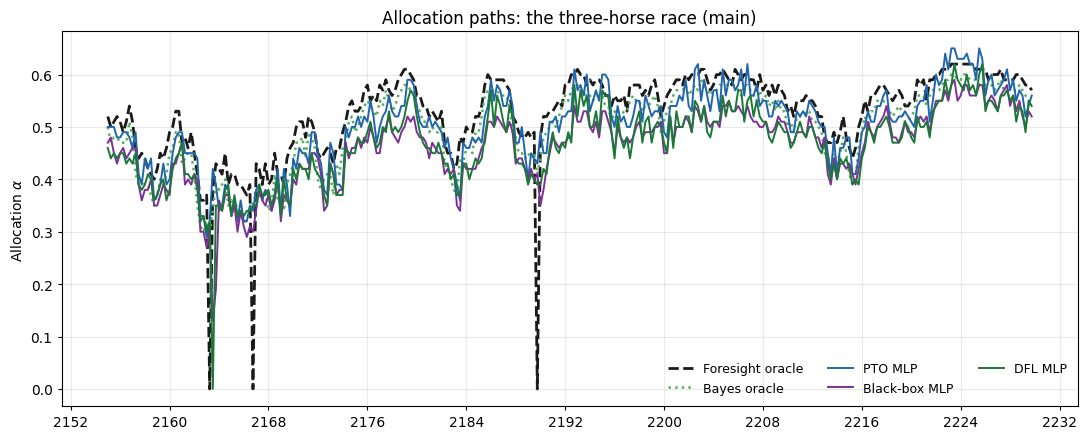

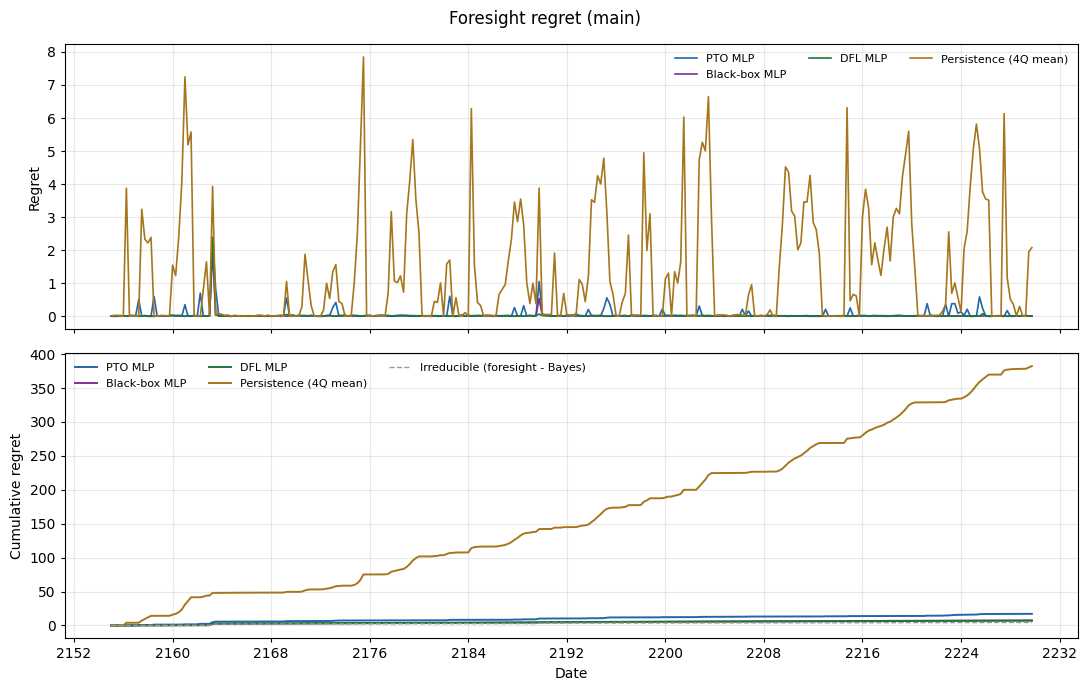

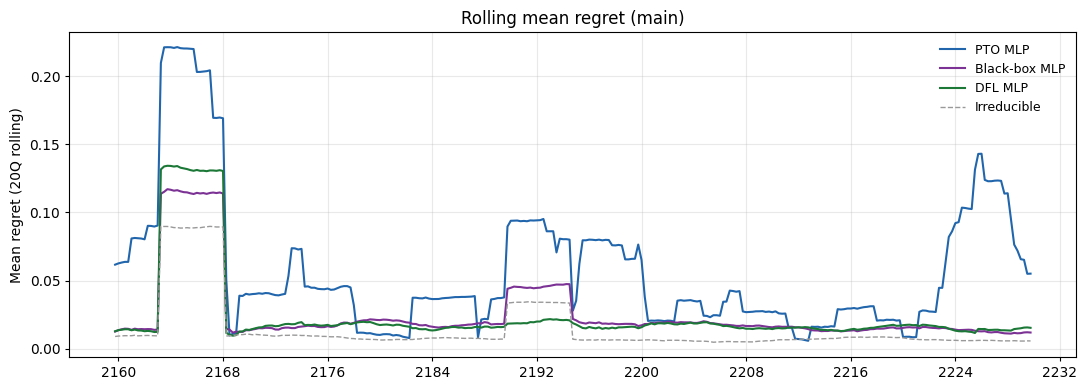

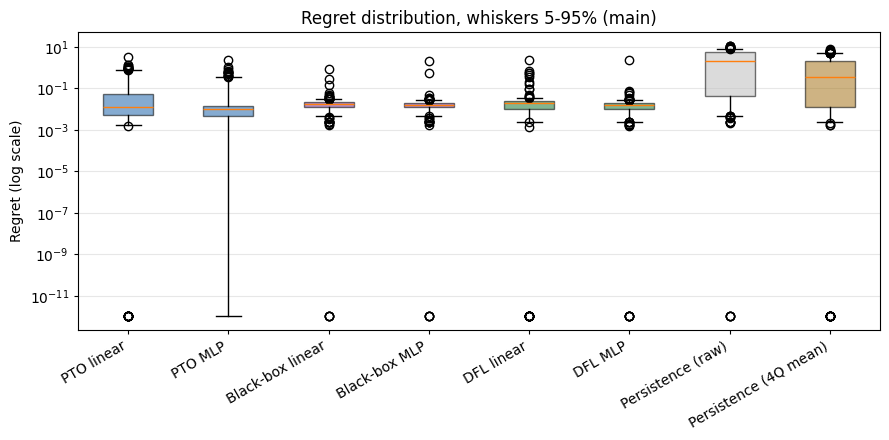

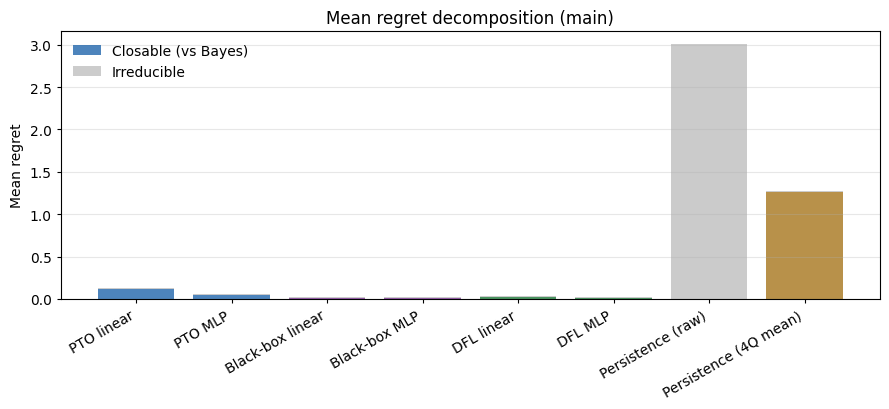

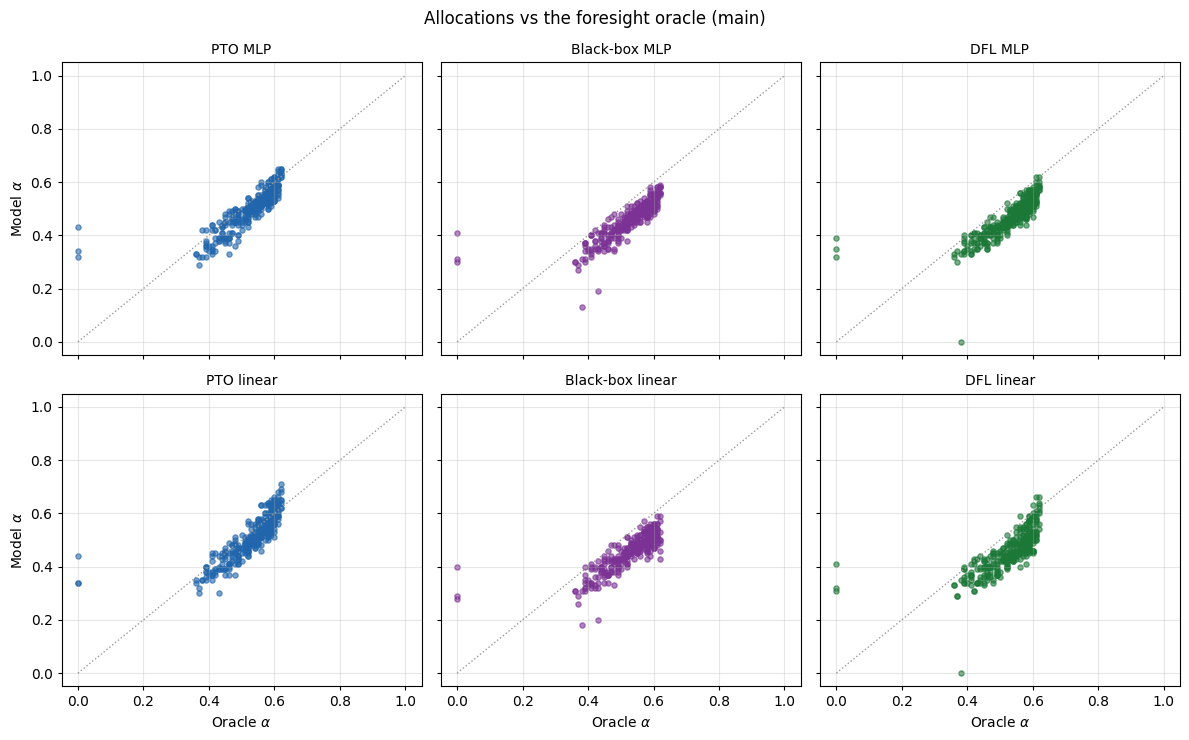

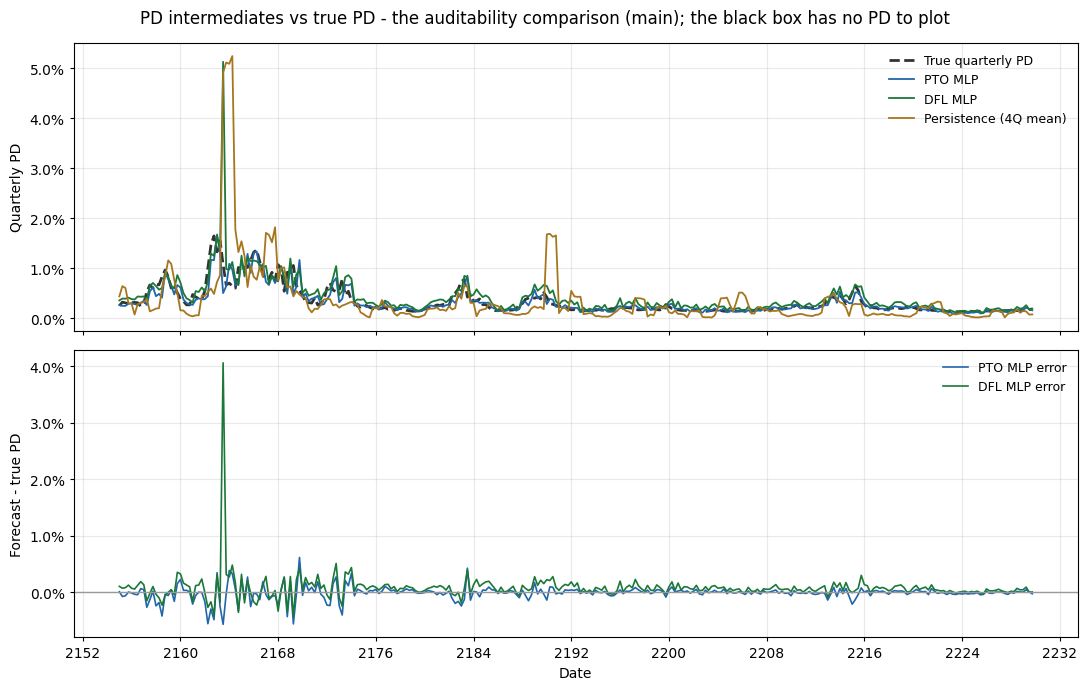

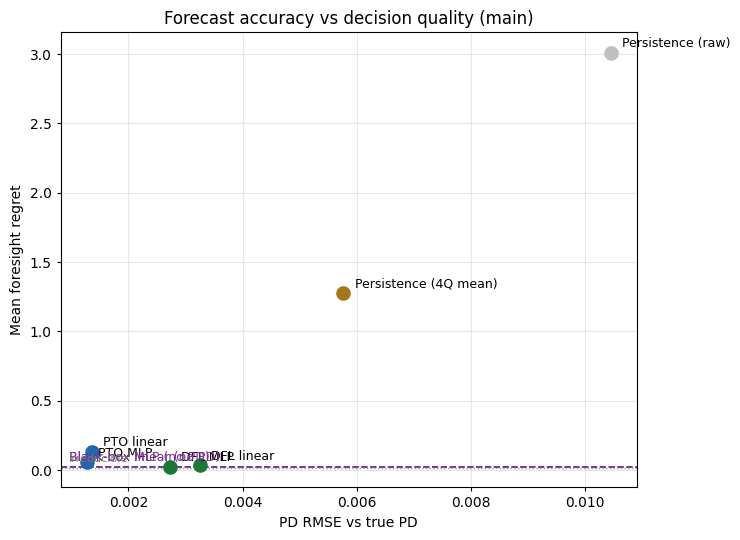

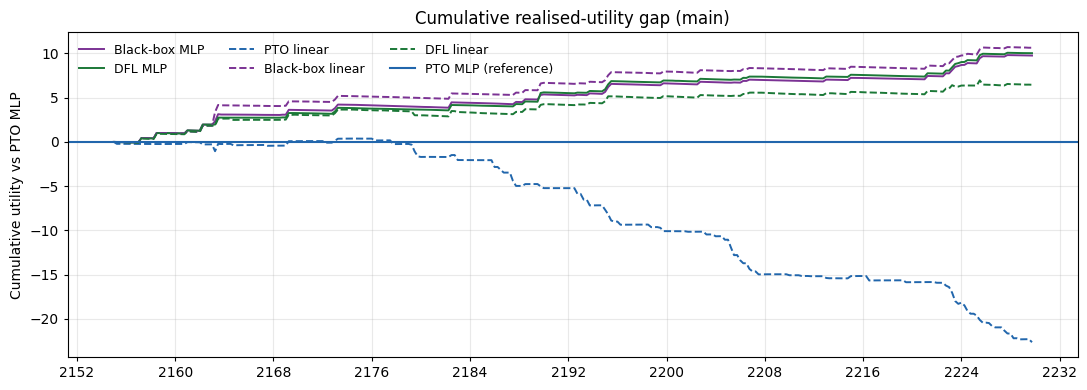

Figures saved to /Users/hannahokeeffe/Documents/Imperial/DFL_New/figures/sim_horserace


In [5]:
# Figure set. HEADLINE = the MLP-class three-horse race; linear variants and baselines
# appear in the panels where they add information rather than clutter.
plot_df = merged.sort_values("date").copy()

# 1. Allocation paths vs oracle and Bayes.
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Foresight oracle")
ax.plot(plot_df["date"], plot_df["alpha_bayes"], color=BAYES_COLOR, lw=1.8, ls=":", label="Bayes oracle")
for m in HEADLINE:
    ax.plot(plot_df["date"], plot_df[f"alpha_hat_{m}"], color=MODEL_COLORS[m], lw=1.4, label=MODEL_LABELS[m])
ax.set_ylabel(r"Allocation $\alpha$"); ax.set_title(f"Allocation paths: the three-horse race ({SPLIT})")
format_date_axis(ax, plot_df); ax.legend(frameon=False, ncol=3, fontsize=9)
fig.tight_layout(); savefig(fig, "alpha_paths_headline.png"); plt.show()

# 2. Per-period and cumulative regret.
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for m in HEADLINE + ["persistence_ma4"]:
    axes[0].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m],
                 lw=1.2, ls=MODEL_LS[m], label=MODEL_LABELS[m])
    axes[1].plot(plot_df["date"], plot_df[f"regret_{m}"].cumsum(), color=MODEL_COLORS[m],
                 lw=1.4, ls=MODEL_LS[m], label=MODEL_LABELS[m])
axes[1].plot(plot_df["date"], plot_df["regret_irreducible"].cumsum(), color="#999999", lw=1.0,
             ls="--", label="Irreducible (foresight - Bayes)")
axes[0].set_ylabel("Regret"); axes[1].set_ylabel("Cumulative regret"); axes[1].set_xlabel("Date")
for ax in axes:
    format_date_axis(ax, plot_df); ax.legend(frameon=False, fontsize=8, ncol=3)
fig.suptitle(f"Foresight regret ({SPLIT})"); fig.tight_layout()
savefig(fig, "regret_and_cumulative.png"); plt.show()

# 3. Rolling mean regret - where in time each horse leads.
fig, ax = plt.subplots(figsize=(11, 4))
for m in HEADLINE:
    ax.plot(plot_df["date"], plot_df[f"regret_{m}"].rolling(ROLL_WINDOW).mean(),
            color=MODEL_COLORS[m], lw=1.5, label=MODEL_LABELS[m])
ax.plot(plot_df["date"], plot_df["regret_irreducible"].rolling(ROLL_WINDOW).mean(),
        color="#999999", lw=1.0, ls="--", label="Irreducible")
ax.set_ylabel(f"Mean regret ({ROLL_WINDOW}Q rolling)")
ax.set_title(f"Rolling mean regret ({SPLIT})")
format_date_axis(ax, plot_df); ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); savefig(fig, "rolling_regret.png"); plt.show()

# 4. Regret distributions (log scale: regret is heavy-tailed by construction).
fig, ax = plt.subplots(figsize=(9, 4.5))
data = [np.maximum(plot_df[f"regret_{m}"].to_numpy(), 1e-12) for m in ALL_MODELS]
_bp_labels = [MODEL_LABELS.get(m, m) for m in ALL_MODELS]
try:  # matplotlib >= 3.9
    bp = ax.boxplot(data, tick_labels=_bp_labels, showfliers=True, whis=(5, 95), patch_artist=True)
except TypeError:  # older matplotlib
    bp = ax.boxplot(data, labels=_bp_labels, showfliers=True, whis=(5, 95), patch_artist=True)
for patch, m in zip(bp["boxes"], ALL_MODELS):
    patch.set_facecolor(MODEL_COLORS[m]); patch.set_alpha(0.55)
ax.set_yscale("log"); ax.set_ylabel("Regret (log scale)")
ax.set_title(f"Regret distribution, whiskers 5-95% ({SPLIT})")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right"); ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout(); savefig(fig, "regret_boxplot.png"); plt.show()

# 5. Mean-regret decomposition: closable (vs Bayes) + irreducible.
fig, ax = plt.subplots(figsize=(9, 4.2))
xs = np.arange(len(ALL_MODELS))
closable = [merged[f"regret_vs_bayes_{m}"].mean() if f"regret_vs_bayes_{m}" in merged else np.nan for m in ALL_MODELS]
irr_mean = merged["regret_irreducible"].mean()
ax.bar(xs, closable, color=[MODEL_COLORS[m] for m in ALL_MODELS], alpha=0.8, label="Closable (vs Bayes)")
ax.bar(xs, irr_mean, bottom=closable, color="#cccccc", label="Irreducible")
ax.set_xticks(xs, [MODEL_LABELS.get(m, m) for m in ALL_MODELS])
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_ylabel("Mean regret"); ax.set_title(f"Mean regret decomposition ({SPLIT})")
ax.legend(frameon=False); ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout(); savefig(fig, "regret_decomposition.png"); plt.show()

# 6. Allocation vs oracle scatter, one panel per headline model (+ linear variants).
show = HEADLINE + HEADLINE_LINEAR
fig, axes = plt.subplots(2, 3, figsize=(12, 7.5), sharex=True, sharey=True)
for ax, m in zip(axes.ravel(), show):
    ax.scatter(plot_df["alpha_oracle"], plot_df[f"alpha_hat_{m}"], s=14,
               color=MODEL_COLORS[m], alpha=0.6)
    ax.plot([0, 1], [0, 1], color="#999999", lw=1, ls=":")
    ax.set_title(MODEL_LABELS[m], fontsize=10); ax.grid(True, alpha=0.3)
for ax in axes[-1]:
    ax.set_xlabel(r"Oracle $\alpha$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"Model $\alpha$")
fig.suptitle(f"Allocations vs the foresight oracle ({SPLIT})")
fig.tight_layout(); savefig(fig, "alpha_vs_oracle_scatter.png"); plt.show()

# 7. PD forecasts vs TRUE PD - the auditability panel (BB has no line here by design).
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(plot_df["date"], plot_df["pd_q_true"], color=TRUE_COLOR, lw=2, ls="--", label="True quarterly PD")
for m in [m for m in ["mlp", "dfl_mlp", "persistence_ma4"] if m in PD_MODELS]:
    axes[0].plot(plot_df["date"], plot_df[f"pd_q_hat_{m}"], color=MODEL_COLORS[m], lw=1.3, label=MODEL_LABELS[m])
axes[0].set_ylabel("Quarterly PD"); axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].legend(frameon=False, fontsize=9)
for m in [m for m in ["mlp", "dfl_mlp"] if m in PD_MODELS]:
    axes[1].plot(plot_df["date"], plot_df[f"pd_q_hat_{m}"] - plot_df["pd_q_true"],
                 color=MODEL_COLORS[m], lw=1.2, label=f"{MODEL_LABELS[m]} error")
axes[1].axhline(0.0, color="#999999", lw=1)
axes[1].set_ylabel("Forecast - true PD"); axes[1].set_xlabel("Date")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0)); axes[1].legend(frameon=False, fontsize=9)
for ax in axes:
    format_date_axis(ax, plot_df)
fig.suptitle(f"PD intermediates vs true PD - the auditability comparison ({SPLIT}); the black box has no PD to plot")
fig.tight_layout(); savefig(fig, "pd_vs_true.png"); plt.show()

# 8. The punchline: forecast accuracy vs decision quality. If DFL sits below the PTO
# point at similar or worse PD accuracy, decision-focused training bought decision
# quality without (or by) sacrificing forecast accuracy. The black box appears as a
# horizontal line: decision quality without any auditable forecast.
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for m in PD_MODELS:
    rmse = float(np.sqrt(((merged[f"pd_q_hat_{m}"] - merged["pd_q_true"]) ** 2).mean()))
    mr = float(merged[f"regret_{m}"].mean())
    ax.scatter(rmse, mr, s=90, color=MODEL_COLORS[m], zorder=3)
    ax.annotate(MODEL_LABELS.get(m, m), (rmse, mr), textcoords="offset points", xytext=(8, 4), fontsize=9)
for m in BB_MODELS:
    mr = float(merged[f"regret_{m}"].mean())
    ax.axhline(mr, color=MODEL_COLORS[m], lw=1.2, ls="--")
    ax.annotate(f"{MODEL_LABELS[m]} (no PD)", (ax.get_xlim()[0], mr),
                textcoords="offset points", xytext=(6, 4), fontsize=9, color=MODEL_COLORS[m])
ax.axhline(merged["regret_irreducible"].mean(), color="#999999", lw=1.0, ls=":")
ax.annotate("Irreducible", (ax.get_xlim()[0], merged["regret_irreducible"].mean()),
            textcoords="offset points", xytext=(6, 4), fontsize=8, color="#777777")
ax.set_xlabel("PD RMSE vs true PD"); ax.set_ylabel("Mean foresight regret")
ax.set_title(f"Forecast accuracy vs decision quality ({SPLIT})")
ax.grid(True, alpha=0.3)
fig.tight_layout(); savefig(fig, "accuracy_vs_decision_quality.png"); plt.show()

# 9. Cumulative utility gap vs PTO MLP - who is ahead, when, and by how much.
fig, ax = plt.subplots(figsize=(11, 4))
ref = plot_df["utility_mlp"]
for m in [m for m in HEADLINE + HEADLINE_LINEAR if m != "mlp"]:
    ax.plot(plot_df["date"], (plot_df[f"utility_{m}"] - ref).cumsum(),
            color=MODEL_COLORS[m], lw=1.4, ls=MODEL_LS[m], label=MODEL_LABELS[m])
ax.axhline(0.0, color=MODEL_COLORS["mlp"], lw=1.5, label="PTO MLP (reference)")
ax.set_ylabel("Cumulative utility vs PTO MLP"); ax.set_title(f"Cumulative realised-utility gap ({SPLIT})")
format_date_axis(ax, plot_df); ax.legend(frameon=False, fontsize=9, ncol=3)
fig.tight_layout(); savefig(fig, "cumulative_utility_gap.png"); plt.show()

print(f"Figures saved to {FIGURES_DIR}")


## Reading the race

A few interpretation notes for the write-up:

- **Mean regret is the headline, but the decomposition matters more**: only
  `regret_vs_bayes` is closable by any model; the irreducible part is the same for
  everyone. A model can only look good on total regret by closing the closable part.
- **Win share vs mean regret**: a model can win most quarters yet lose on mean regret
  if it blows up in stress quarters - the regime table and rolling-regret figure show
  who is robust rather than merely usually-fine.
- **The accuracy-vs-decision-quality scatter is the thesis in one picture**: PTO should
  anchor the low-PD-RMSE end; if DFL sits at lower regret despite similar-or-worse PD
  accuracy, decision-focused training converted forecast error into the error metric
  that matters. The black box appears only as a horizontal line - decision quality
  with no auditable forecast at any accuracy.
- **Sample-length sweep**: rerun notebooks 02-04 with shorter training samples and
  re-run this notebook per sweep point to produce the "DFL advantage vs sample size"
  figure; the same applies to a lambda sweep. This notebook is deliberately cheap so
  it can be re-run per sweep configuration.